# Tarot Card Dataset — Exploratory Data Analysis


### 1. Import Libraries

In [ ]:
import os
import re
import json
import glob
import random
import hashlib
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

## 2. Load dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
JSON_PATH = "/content/tarot-images.json"
CARDS_DIR = "/content/drive/MyDrive/infosys internship/Cards"

with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

if isinstance(raw_data, dict):
    list_keys = [k for k, v in raw_data.items() if isinstance(v, list)]
    records = raw_data[list_keys[0]] if list_keys else [raw_data]
else:
    records = raw_data

df = pd.json_normalize(records)
print(f"Loaded and normalized JSON with shape: {df.shape}")


Loaded and normalized JSON with shape: (78, 17)


In [ ]:
df.head()

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...","[Listening to your feelings and intuitions, Ex...","[Being aloof, Obsessing on secrets and conspir...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,"[Nurturing yourself and others, Bearing fruit,...","[Overindulging, Being greedy, Smothering someo...",NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,"[Exercising authority, Defining limits, Direct...","[Micromanaging, Crushing the creativity of oth...",NaN,NaN


In [ ]:
df.tail()

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
73,Ten of Pentacles,10,Minor Arcana,Pentacles,p10.jpg,"[Big money is in the near future, Expect a pow...","[wealth, abundance, acquisition, greed]",NaN,NaN,"10 (The End: finality, completion, exhaustion)",NaN,NaN,"[How much stuff do I really need?, How do I fe...",[Celebrating your physical and financial bless...,[Spending all of your money on extravagant gif...,Mercury in Virgo,"""I keep physical and financial matters in pers..."
74,Page of Pentacles,11,Minor Arcana,Pentacles,p11.jpg,[This card represents a young man or woman wit...,"[practicality, prosperity, learning, growth, a...",NaN,NaN,NaN,Earth of Earth.,NaN,[How can you get more financial or sexual expe...,"[Learning the value of a dollar, Starting a sa...",[Trying to appear healthier or wealthier than ...,NaN,"""I am physically and financially responsible."""
75,Knight of Pentacles,12,Minor Arcana,Pentacles,p12.jpg,[A stingy person may chide you for spending mo...,"[caution, focus, realism, invention]",NaN,NaN,NaN,Air of Earth.,NaN,[What's the difference between caution and fea...,"[Spending money wisely, Saving for a rainy day...","[Throwing caution to the four winds, Spending ...",NaN,"""I temper my actions with cautious optimism."""
76,Queen of Pentacles,13,Minor Arcana,Pentacles,p13.jpg,[This card represents a woman with an expansiv...,"[luxury, comfort, resourcefulness, generosity,...",NaN,NaN,NaN,Water of Earth.,NaN,"[How do I define luxury?, To what extent am I ...","[Appreciating fine food, fine wine, beautiful ...","[Indulging in gluttony or greediness, Becoming...",NaN,"""I relish the best this world has to offer."""
77,King of Pentacles,14,Minor Arcana,Pentacles,p14.jpg,[This card represents an older man with a fina...,"[stability, dependability, confidence, interve...",NaN,NaN,NaN,Fire of Earth.,NaN,[How can you handle expenses with greater conf...,"[Becoming debt-free, Having more than enough t...",[Becoming so conservative you resist all chang...,NaN,"""I embody confidence and fairness."""


In [ ]:
print(f"Shape (rows, columns): {df.shape}")
print(f"Columns: {list(df.columns)}")

name_col = "name"
arcana_col = "arcana"
suit_col = "suit"
keywords_col = "keywords"
desc_col = "meaning_up"

Shape (rows, columns): (78, 17)
Columns: ['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'meanings.light', 'meanings.shadow', 'Astrology', 'Affirmation']


In [ ]:
missing = df.isnull().sum().to_frame(name="missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_percent
Archetype,56,71.79
Hebrew Alphabet,56,71.79
Mythical/Spiritual,56,71.79
Elemental,40,51.28
Astrology,38,48.72
Affirmation,22,28.21
Numerology,16,20.51


In [ ]:
list_cols = [col for col in df.columns if df[col].apply(lambda x: isinstance(x, list)).any()]

if list_cols:
    df_for_duplicate_check = df.drop(columns=list_cols)
else:
    df_for_duplicate_check = df.copy()

n_duplicates = df_for_duplicate_check.duplicated().sum()
print(f"Number of fully duplicated rows : {n_duplicates}")

Number of fully duplicated rows : 0


## 3. JSON / Metadata Analysis


In [ ]:
if name_col:
    print(f"Total unique card names: {df[name_col].nunique()}")

if arcana_col:
    print("\nArcana distribution:")
    display(df[arcana_col].value_counts())

if suit_col:
    print("\nSuit distribution:")
    display(df[suit_col].value_counts())

Total unique card names: 78

Arcana distribution:


,count
arcana,
Minor Arcana,56
Major Arcana,22



Suit distribution:


,count
suit,
Trump,22
Cups,14
Swords,14
Wands,14
Pentacles,14


## 4. Image Dataset Analysis


In [ ]:
def list_images(root_dir, extensions=(".jpg", ".jpeg", ".png", ".bmp", ".webp")):
    paths = []
    for ext in extensions:
        paths.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext}"), recursive=True))
        paths.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext.upper()}"), recursive=True))
    return sorted(set(paths))

image_paths = list_images(CARDS_DIR)
print(f"Total tarot card images found: {len(image_paths)}")

Total tarot card images found: 78


In [ ]:
file_types = Counter(os.path.splitext(p)[1].lower() for p in image_paths)
pd.DataFrame(file_types.items(), columns=["extension", "count"]).sort_values("count", ascending=False)

,extension,count
0,.jpg,78


## 5. Resolution Analysis


In [ ]:
SAMPLE_SIZE = min(500, len(image_paths))
sample_paths = random.sample(image_paths, SAMPLE_SIZE)

resolutions = []
corrupted_images = []

for path in tqdm(sample_paths):
    try:
        with Image.open(path) as img:
            resolutions.append(img.size)
    except:
        corrupted_images.append(path)

print(f"Processed Images: {len(resolutions)}")
print(f"Corrupted Images: {len(corrupted_images)}")

  0%|          | 0/78 [00:00<?, ?it/s]

Processed Images: 78
Corrupted Images: 0


In [ ]:
if resolutions:
    widths = [w for w, h in resolutions]
    heights = [h for w, h in resolutions]

    res_stats = pd.DataFrame({
        "width":  [min(widths), max(widths), np.mean(widths), np.median(widths)],
        "height": [min(heights), max(heights), np.mean(heights), np.median(heights)],
    }, index=["min", "max", "mean", "median"]).round(1)
    print("Resolution statistics:")
    display(res_stats)
else:
    print("ℹ️ No image resolutions available for statistics. Please ensure images are uploaded and processed.")
    res_stats = pd.DataFrame(columns=["width", "height"], index=["min", "max", "mean", "median"]) # Create an empty DataFrame

Resolution statistics:


,width,height
min,350.0,600.0
max,350.0,600.0
mean,350.0,600.0
median,350.0,600.0


## 6. File Size Analysis

File size statistics (KB):
min      72.05
max     124.04
mean     96.75
dtype: float64


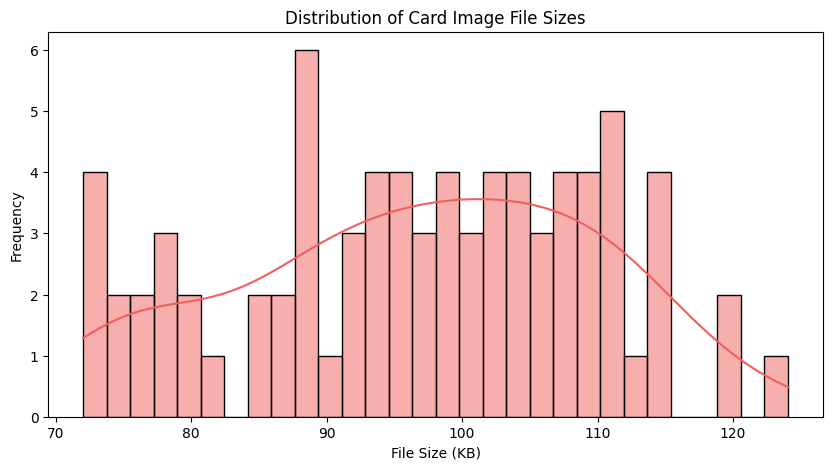

In [ ]:
file_sizes = [os.path.getsize(p) / 1024 for p in image_paths]

# Define a color palette if not already defined
if 'PALETTE' not in locals():
    PALETTE = sns.color_palette("magma", n_colors=5)

size_stats = pd.Series(file_sizes).describe()[["min", "max", "mean"]].round(2)
print("File size statistics (KB):")
print(size_stats)
plt.figure(figsize=(10, 5))
sns.histplot(file_sizes, bins=30, color=PALETTE[3], kde=True)
plt.title("Distribution of Card Image File Sizes")
plt.xlabel("File Size (KB)")
plt.ylabel("Frequency")
plt.show()

## 7. Brightness Analysis


Calculating brightness:   0%|          | 0/78 [00:00<?, ?it/s]

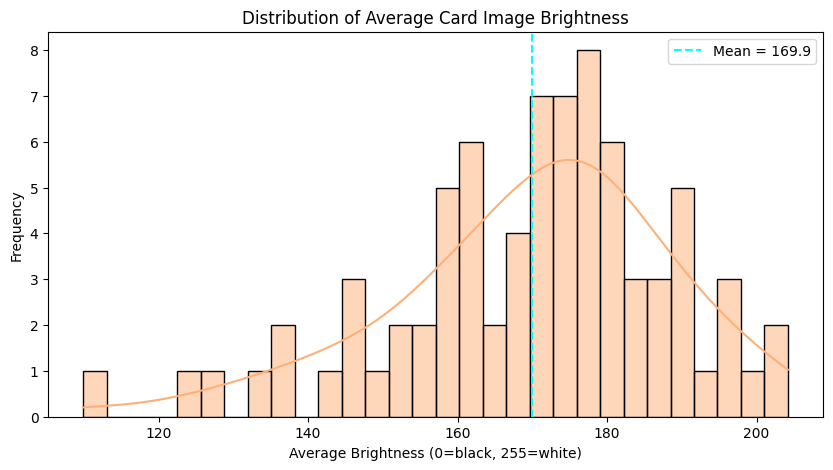

Mean brightness: 169.92
Std brightness:  18.45


In [ ]:
brightness_values = []
corrupted_brightness_images = []

for path in tqdm(image_paths, desc="Calculating brightness"):
    try:
        with Image.open(path).convert("L") as img:  # Convert to grayscale
            brightness_values.append(np.mean(np.array(img)))
    except Exception as e:
        corrupted_brightness_images.append((path, str(e)))

plt.figure(figsize=(10, 5))
sns.histplot(brightness_values, bins=30, color=PALETTE[4], kde=True)
plt.axvline(np.mean(brightness_values), color="cyan", linestyle="--", label=f"Mean = {np.mean(brightness_values):.1f}")
plt.title("Distribution of Average Card Image Brightness")
plt.xlabel("Average Brightness (0=black, 255=white)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Mean brightness: {np.mean(brightness_values):.2f}")
print(f"Std brightness:  {np.std(brightness_values):.2f}")

if corrupted_brightness_images:
    print(f"\nWarning: {len(corrupted_brightness_images)} images could not be processed for brightness analysis.")
    for path, err in corrupted_brightness_images:
        print(f"  - {path}: {err}")

## 8. Random Card Visualization



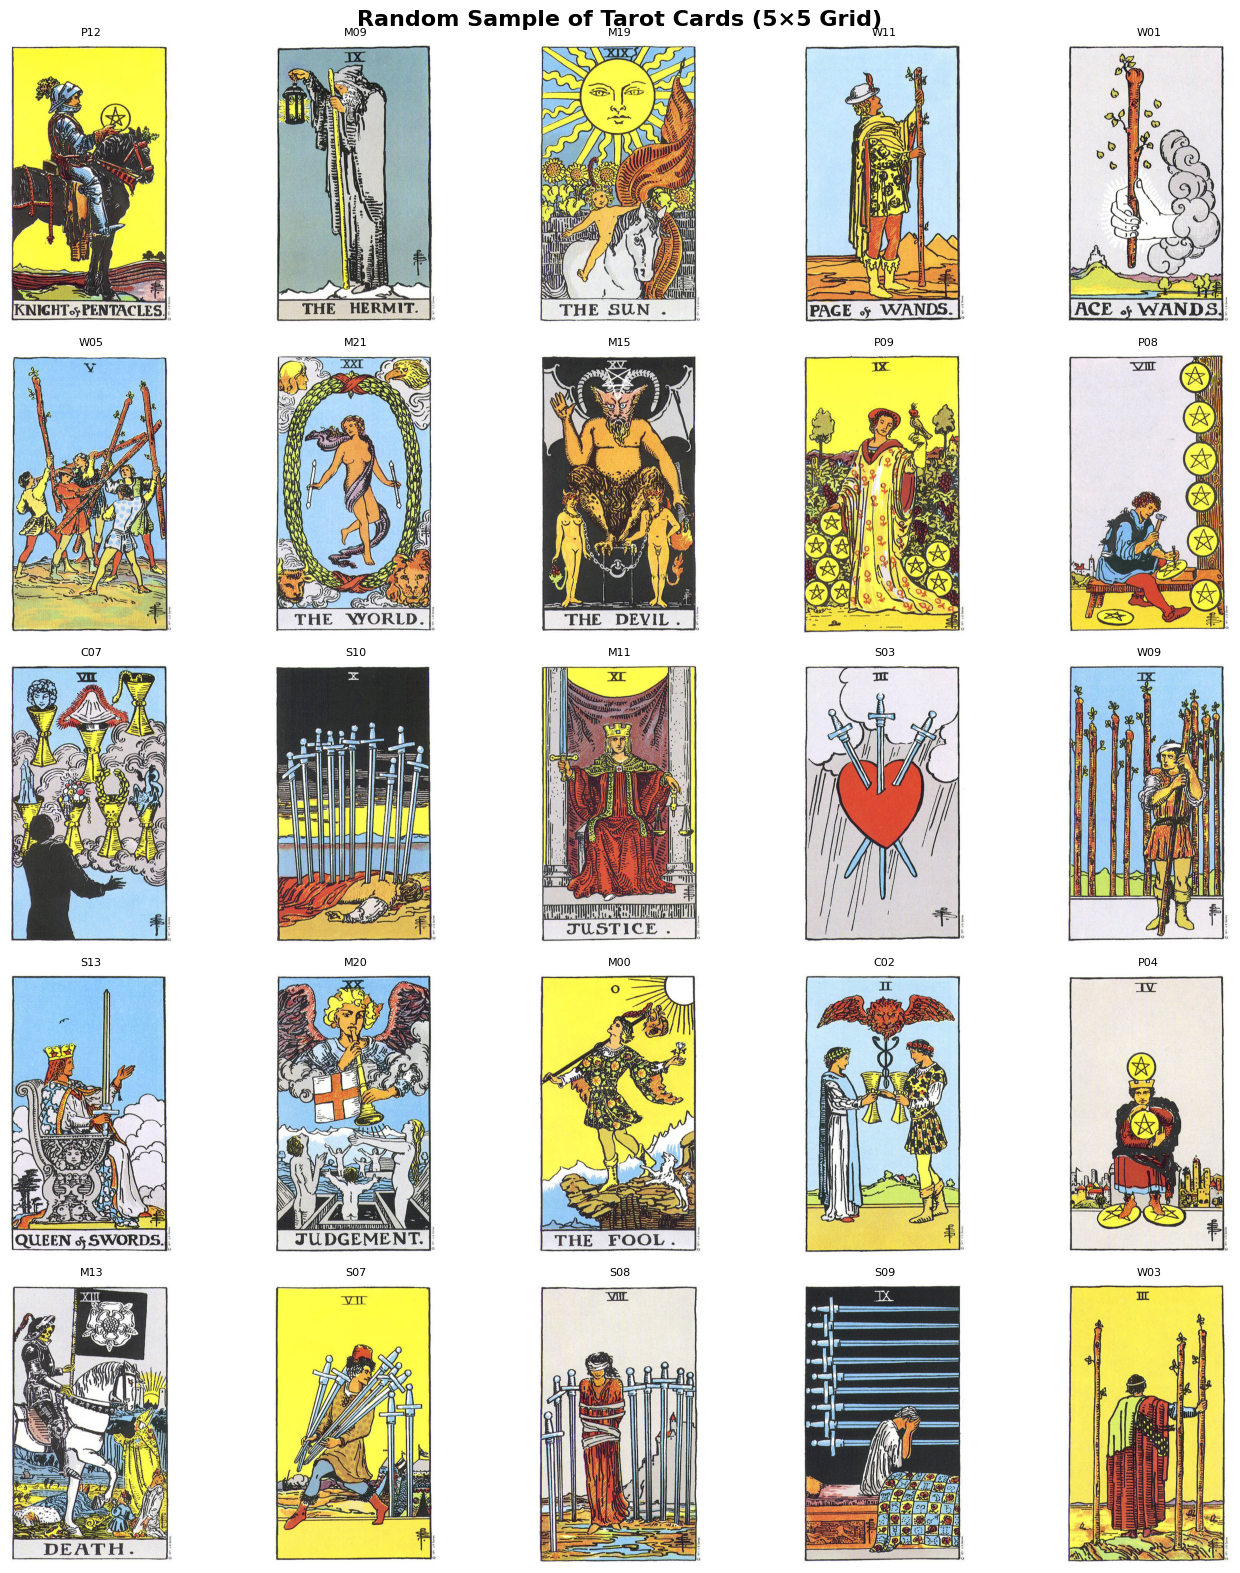

In [ ]:
sample_grid_paths = random.sample(image_paths, min(25, len(image_paths)))

fig, axes = plt.subplots(5, 5, figsize=(14, 16))
for ax, path in zip(axes.flatten(), sample_grid_paths):
    try:
        img = Image.open(path)
        ax.imshow(img)
        card_name = os.path.splitext(os.path.basename(path))[0].replace("_", " ").title()
        ax.set_title(card_name, fontsize=8)
    except Exception:
        ax.set_title("unreadable", fontsize=8)
    ax.axis("off")

plt.suptitle("Random Sample of Tarot Cards (5×5 Grid)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Corrupted Image Detection


In [ ]:
if corrupted_images:
    print(f"Found {len(corrupted_images)} corrupted/unreadable image(s):")
    for path, err in corrupted_images:
        print(f"  - {path} → {err}")
else:
    print("No corrupted images detected in the sampled set.")

No corrupted images detected in the sampled set.


## 10. Duplicate Image Detection


In [ ]:
image_hashes = defaultdict(list)
corrupted_hash_images = []

for path in tqdm(image_paths, desc="Calculating image hashes"):
    try:
        with open(path, "rb") as f:
            data = f.read()
            image_hashes[hashlib.md5(data).hexdigest()].append(path)
    except Exception as e:
        corrupted_hash_images.append((path, str(e)))

duplicate_groups = {h: paths for h, paths in image_hashes.items() if len(paths) > 1}
total_duplicate_files = sum(len(v) - 1 for v in duplicate_groups.values())

print(f"Duplicate groups found: {len(duplicate_groups)}")

if corrupted_hash_images:
    print(f"\nWarning: {len(corrupted_hash_images)} images could not be processed for hashing.")
    for path, err in corrupted_hash_images:
        print(f"  - {path}: {err}")

Calculating image hashes:   0%|          | 0/78 [00:00<?, ?it/s]

Duplicate groups found: 0


## 11. JSON Missing Values


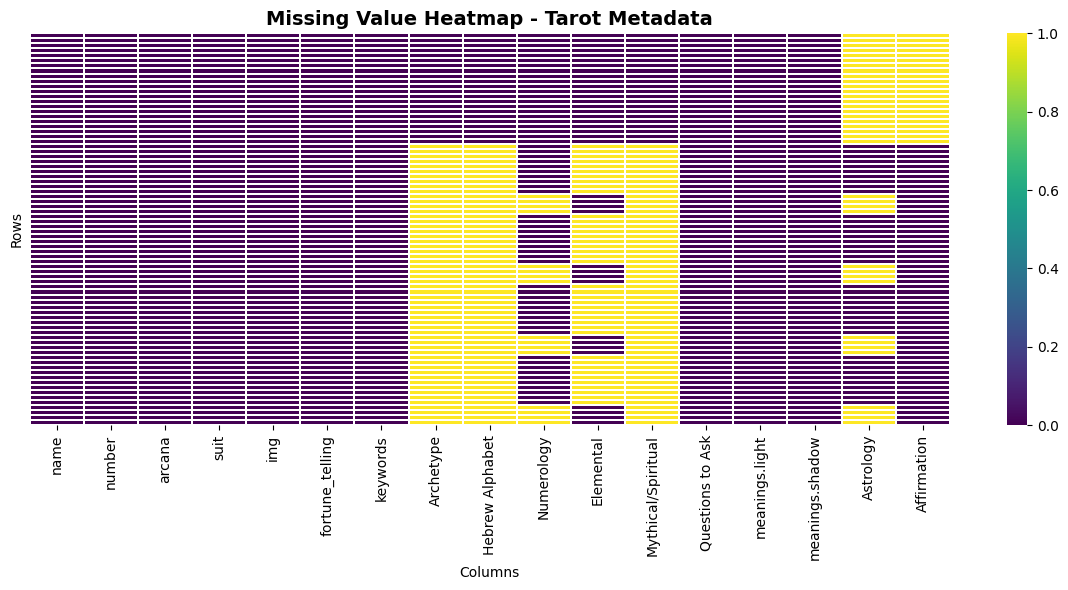

Columns with Missing Values:
Archetype             56
Hebrew Alphabet       56
Mythical/Spiritual    56
Elemental             40
Astrology             38
Affirmation           22
Numerology            16
dtype: int64


In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=True,
    yticklabels=False,
    linewidths=0.2,
    linecolor="white"
)

plt.title("Missing Value Heatmap - Tarot Metadata", fontsize=14, fontweight="bold")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print("Columns with Missing Values:")
    print(missing_summary)
else:
    print("No missing values found in the Tarot metadata.")

## 12. Card Category Analysis



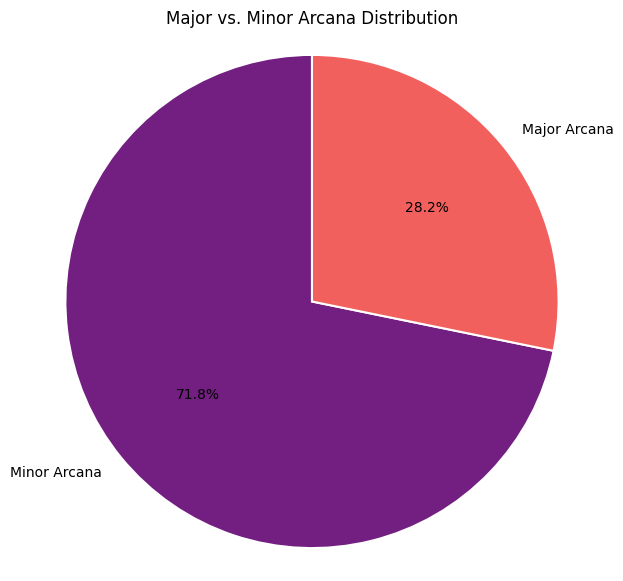

,count
arcana,
Minor Arcana,56
Major Arcana,22


In [ ]:
if arcana_col:
    arcana_counts = df[arcana_col].value_counts()
    plt.figure(figsize=(7, 7))
    plt.pie(arcana_counts.values, labels=arcana_counts.index.astype(str), autopct="%1.1f%%",
            colors=sns.color_palette("magma", len(arcana_counts)), startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    plt.title("Major vs. Minor Arcana Distribution")
    plt.axis("equal")
    plt.show()
    display(arcana_counts.to_frame(name="count"))
else:
    print("No arcana column detected — skipping arcana distribution chart.")

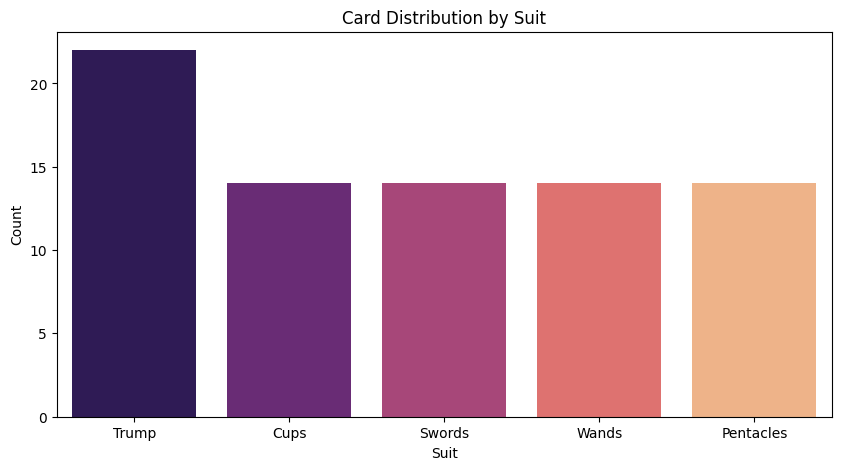

In [ ]:
if suit_col:
    suit_counts = df[suit_col].value_counts()
    plt.figure(figsize=(10, 5))
    sns.barplot(x=suit_counts.index.astype(str), y=suit_counts.values, palette="magma")
    plt.title("Card Distribution by Suit")
    plt.xlabel("Suit")
    plt.ylabel("Count")
    plt.show()
else:
    print("No suit column detected — skipping suit distribution chart.")

## 13. Dataset Quality Report



In [ ]:
quality_report = {
    "Total card images (directory scan)": len(image_paths),
    "Images analyzed in this sample": len(resolutions),
    "Metadata records (JSON)": len(df),
    "Unique card names": df[name_col].nunique() if name_col else "N/A",
    "Corrupted images (sample)": len(corrupted_images),
    "Duplicate groups (sample)": len(duplicate_groups),
    "Redundant duplicate files (sample)": total_duplicate_files,
    "Missing values (JSON, total cells)": int(df.isnull().sum().sum()),
    "Duplicate JSON rows": int(n_duplicates),
    "Mean image width": round(np.mean(widths), 1),
    "Mean image height": round(np.mean(heights), 1),
    "Mean file size (KB)": round(np.mean(file_sizes), 2),
    "Mean brightness": round(np.mean(brightness_values), 2),
}

report_df = pd.DataFrame(quality_report.items(), columns=["Metric", "Value"])
report_df

,Metric,Value
0,Total card images (directory scan),78.00
1,Images analyzed in this sample,78.00
2,Metadata records (JSON),78.00
3,Unique card names,78.00
4,Corrupted images (sample),0.00
5,Duplicate groups (sample),0.00
6,Redundant duplicate files (sample),0.00
7,"Missing values (JSON, total cells)",284.00
8,Duplicate JSON rows,0.00
9,Mean image width,350.00
